**Liquor Sales in Iowa**


This is my first data analysis project!

I know that it won't be perfect put I'll do a descent work, explaining each step and the thinking behind.

The goal is to derive useful insights from row data - the magic of data analysis.

In [ ]:
# Setting up the environment by importing all the needed libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# Load the data and have a look on the first 5 rows of the dataset
df = pd.read_csv('https://storage.googleapis.com/courses_data/Assignment%20CSV/finance_liquor_sales.csv')
df.head()

,invoice_and_item_number,date,store_number,store_name,address,city,zip_code,store_location,county_number,county,...,item_number,item_description,pack,bottle_volume_ml,state_bottle_cost,state_bottle_retail,bottles_sold,sale_dollars,volume_sold_liters,volume_sold_gallons
0,INV-31797900035,2020-11-10,4967,Jeff's Market / Blue Grass,"102, W Mayne St",Blue Grass,52726.0,POINT (-90.766126 41.509119),82.0,SCOTT,...,26858,Templeton 4YR Rye,12,375,9.99,14.99,1,14.99,0.37,0.09
1,INV-23548800092,2019-11-27,2601,Hy-Vee Food Store / Fairfield,1300 West Burlington Ave,Fairfield,52556.0,POINT (-91.978702 41.006456),51.0,JEFFERSON,...,86251,Juarez Triple Sec,12,1000,2.42,3.63,6,21.78,6.00,1.58
2,INV-23609300026,2019-12-02,4962,Hilltop Grocery,1312 Harrison St,Davenport,52803.0,NaN,82.0,SCOTT,...,41844,Everclear Alcohol,24,375,4.20,6.30,3,18.90,1.12,0.29
3,INV-39482900037,2021-08-24,3719,Wal-Mart 0581 / Marshalltown,2802 S Center St,Marshalltown,50158.0,POINT (-92.91231 42.012918),64.0,MARSHALL,...,65259,Jagermeister Liqueur Mini Meisters,12,20,4.93,7.40,12,88.80,0.24,0.06
4,INV-39520400088,2021-08-25,5423,Stammer Liquor Corp,615 2nd Ave,Sheldon,51201.0,POINT (-95.854899 43.184242),71.0,OBRIEN,...,77487,Tortilla Gold DSS,12,1000,4.85,7.28,4,29.12,4.00,1.05


As a first action we have to ensure that the date column has datetime values because date is (almost always) a very useful column and we eventualy will have to manipulate it in order to express other attributes in relation with it and their change over time.

In [ ]:
df["date"] = pd.to_datetime(df["date"])

In [ ]:
# Get a summary of the dataset (and also making sure that the previous datetime change)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 24 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   invoice_and_item_number  200 non-null    object        
 1   date                     200 non-null    datetime64[ns]
 2   store_number             200 non-null    int64         
 3   store_name               200 non-null    object        
 4   address                  200 non-null    object        
 5   city                     200 non-null    object        
 6   zip_code                 200 non-null    float64       
 7   store_location           182 non-null    object        
 8   county_number            199 non-null    float64       
 9   county                   199 non-null    object        
 10  category                 197 non-null    float64       
 11  category_name            191 non-null    object        
 12  vendor_number            200 non-nul

In [ ]:
# Get a very useful statistical description of the values so we can see the range of the values of each attribute (mean, stdv, min, max etc)
df.describe()

,date,store_number,zip_code,county_number,category,vendor_number,item_number,pack,bottle_volume_ml,state_bottle_cost,state_bottle_retail,bottles_sold,sale_dollars,volume_sold_liters,volume_sold_gallons
count,200,200.00000,200.000000,199.000000,1.970000e+02,200.00000,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000
mean,2017-08-02 02:24:00,3658.46500,51367.520000,55.351759,1.167075e+06,279.87500,99695.930000,11.560000,841.975000,10.041200,15.065600,54.925000,717.367050,51.376500,13.570450
min,2012-01-17 00:00:00,2178.00000,50009.000000,3.000000,1.011300e+06,35.00000,168.000000,3.000000,20.000000,0.890000,1.340000,1.000000,6.750000,0.150000,0.030000
25%,2015-01-02 12:00:00,2593.00000,50401.000000,32.000000,1.051110e+06,107.50000,35916.000000,6.000000,750.000000,4.690000,7.040000,4.000000,46.867500,4.000000,1.060000
50%,2017-06-17 00:00:00,3509.00000,51301.000000,57.000000,1.081330e+06,303.00000,66772.500000,12.000000,750.000000,7.620000,11.430000,22.000000,206.640000,7.500000,1.980000
75%,2020-09-02 06:00:00,4358.75000,52314.000000,77.000000,1.091200e+06,421.00000,82847.500000,12.000000,1000.000000,15.000000,22.500000,66.000000,808.380000,55.125000,14.565000
max,2022-06-28 00:00:00,9001.00000,52807.000000,97.000000,1.901200e+06,662.00000,986845.000000,48.000000,1750.000000,34.990000,52.490000,900.000000,7240.860000,900.000000,237.750000
std,NaN,1207.00655,945.237701,27.128331,2.482830e+05,152.99154,195813.621412,6.895953,441.554727,6.986453,10.481138,108.227656,1214.452206,112.315307,29.670376


In [ ]:
# Find if there are any null values
df.isnull().sum()

,0
invoice_and_item_number,0
date,0
store_number,0
store_name,0
address,0
city,0
zip_code,0
store_location,18
county_number,1
county,1


In [ ]:
# Droping all rows with any missing values and see the remaining rows
df_cleaned = df.dropna()
df_cleaned.info()

<class 'pandas.core.frame.DataFrame'>
Index: 173 entries, 0 to 198
Data columns (total 24 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   invoice_and_item_number  173 non-null    object        
 1   date                     173 non-null    datetime64[ns]
 2   store_number             173 non-null    int64         
 3   store_name               173 non-null    object        
 4   address                  173 non-null    object        
 5   city                     173 non-null    object        
 6   zip_code                 173 non-null    float64       
 7   store_location           173 non-null    object        
 8   county_number            173 non-null    float64       
 9   county                   173 non-null    object        
 10  category                 173 non-null    float64       
 11  category_name            173 non-null    object        
 12  vendor_number            173 non-null    

As we already knew that we dorp 27 rows. This is 13,5% of data.
This percentage is not that small to allow us to drop all the rows without caution. But let's examine further where we found this NAs.

It's very improtant that the missing/null values exist mostly in store_location attribute. Once this attribute is not so useful for the analysis because it does not contain that much of insightful info, we could just keep these rows in order to save the info given but the other attributes.

Alothough, I decided to drop them for two main reasons. Firstly, the majority of the rest exist in the column category_name (a inshightful attribute) and secondly, mostly because we often tend to drop (at least) some rows and I'd like to work with a cleaned dataset - just like a real world scenario.

(We could also have tried to fill these NA values with the mean of each column and avoid all the above thoughts but the missing values belong to categorical data and I didn't want to fill with the categorical mode of such a small dataset.)

In [ ]:
# Create a new subset that contains only the numeric columns
numeric_df_clean = df_cleaned.select_dtypes(include=['number'])
numeric_df_clean.head()

,store_number,zip_code,county_number,category,vendor_number,item_number,pack,bottle_volume_ml,state_bottle_cost,state_bottle_retail,bottles_sold,sale_dollars,volume_sold_liters,volume_sold_gallons
0,4967,52726.0,82.0,1011600.0,255.0,26858,12,375,9.99,14.99,1,14.99,0.37,0.09
1,2601,52556.0,51.0,1081500.0,434.0,86251,12,1000,2.42,3.63,6,21.78,6.00,1.58
3,3719,50158.0,64.0,1082100.0,192.0,65259,12,20,4.93,7.40,12,88.80,0.24,0.06
4,5423,51201.0,71.0,1092100.0,421.0,77487,12,1000,4.85,7.28,4,29.12,4.00,1.05
5,3842,50517.0,55.0,1091100.0,578.0,77055,6,750,13.01,19.52,18,351.36,13.50,3.56


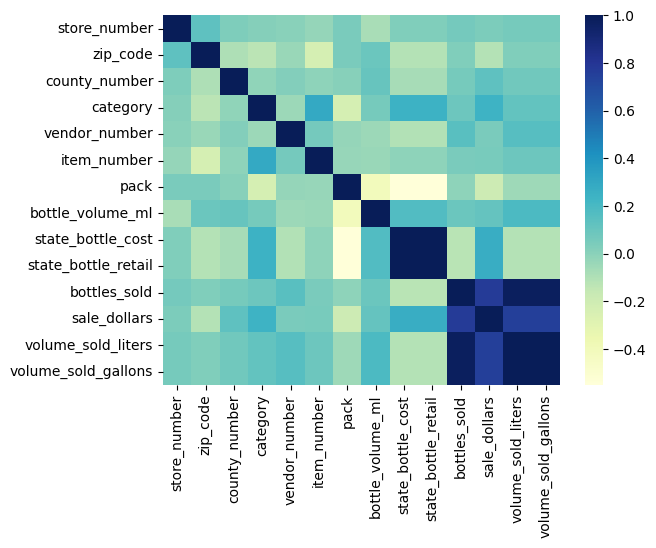

In [ ]:
# Using the numeric data-subset to find out if there are strong correlations between numeric attributes
sns.heatmap(numeric_df_clean.corr(), cmap='YlGnBu')
plt.show()

We got a first look on the dataset.


The statistics helped us understand better the dataset and the values of each attribute, something that will help us in the next steps of the analysis.

The heatmap does not show any interesting correlations beyond the expected (logical) ones: state_bottle_cost - state_bottle_retail, bottles_sold - volumn_sold_liters/gallons and pack-state_bottle_cost/retail.


Let's continue with some further data handling and visualizations in order to extract meaningful insights.

In [ ]:
# Calculate total sale_dollars for each city
city_sales = df.groupby('city')['sale_dollars'].sum().reset_index()

# Sort cities by total sale_dollars in descending order and select the top 20
top_20_cities_by_sales = city_sales.sort_values(by='sale_dollars', ascending=False).head(20)

# Get the list of top 20 city names in the desired order
city_order = top_20_cities_by_sales['city'].tolist()

# Filter the original DataFrame to include only the top 20 cities by sales
filtered_city_data_by_sales = df[df['city'].isin(city_order)]

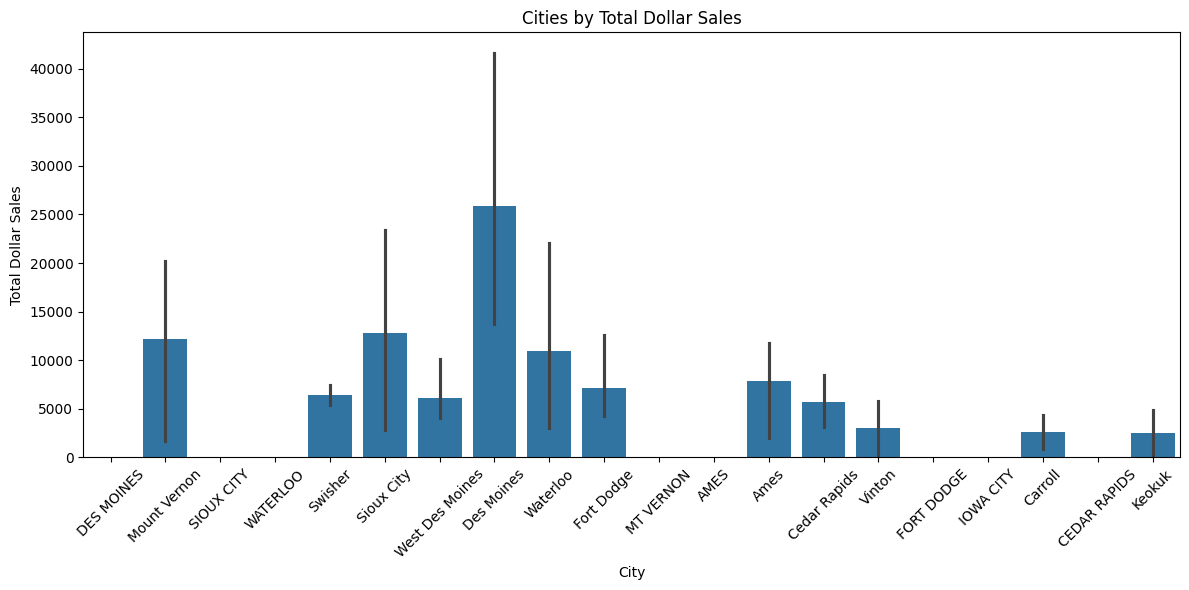

In [ ]:
# Now, use this filtered data for plotting
plt.figure(figsize=(12, 6))
sns.barplot(x='city', y='sale_dollars', data=filtered_city_data_by_sales, order=city_order, estimator=sum)
plt.title('Cities by Total Dollar Sales')
plt.xlabel('City')
plt.ylabel('Total Dollar Sales')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

This plot is still far from we want to see but we'll get there.

A specific thing that got my attetion first is the fact that if we look closely to the outcome we can easily see that some cities appear two times (DES MOINES, Des Moines)

In [ ]:
# Group by lowercase version and count frequency
city_counts = df.groupby(df['city'].str.lower())['city'].transform('size')

# Filter rows where lowercase value appears more than once
duplicates = df[city_counts > 1]

print("Case-insensitive duplicates:")
print(duplicates['city'])

Case-insensitive duplicates:
2           Davenport
3        Marshalltown
6      COUNCIL BLUFFS
7           MUSCATINE
8          DES MOINES
            ...      
195            Vinton
196        Fort Dodge
197        DES MOINES
198         DAVENPORT
199            MARION
Name: city, Length: 155, dtype: object


We can see some case-sensitive values like "Davenport" and "DAVENPORT", so we have to normalize this column in order to gain trusted and right insights.

In [ ]:
# We normilize the city names and remove the whitespace
filtered_city_data_by_sales['city'] = filtered_city_data_by_sales['city'].str.title()
filtered_city_data_by_sales['city'] = filtered_city_data_by_sales['city'].str.strip().str.title()

/tmp/ipython-input-13-1846753842.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_city_data_by_sales['city'] = filtered_city_data_by_sales['city'].str.title()
/tmp/ipython-input-13-1846753842.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_city_data_by_sales['city'] = filtered_city_data_by_sales['city'].str.strip().str.title()


In [ ]:
city_counts = filtered_city_data_by_sales.groupby(filtered_city_data_by_sales['city'].str.lower())['city'].transform('size')
duplicates = filtered_city_data_by_sales[city_counts > 1]

print("Remaining case-insensitive duplicates:")
print(duplicates['city'])

Remaining case-insensitive duplicates:
8        Des Moines
12         Waterloo
15       Des Moines
16       Sioux City
17         Waterloo
           ...     
192      Des Moines
194    Cedar Rapids
195          Vinton
196      Fort Dodge
197      Des Moines
Name: city, Length: 86, dtype: object


In [ ]:
# Make a copy and normalize city names
df_normalized = df.copy()
df_normalized['city'] = df_normalized['city'].str.strip().str.title()

# Group by normalized city and sum sales
city_sales = df_normalized.groupby('city', as_index=False)['sale_dollars'].sum()

top_20_cities_by_sales = city_sales.sort_values(by='sale_dollars', ascending=False).head(20)

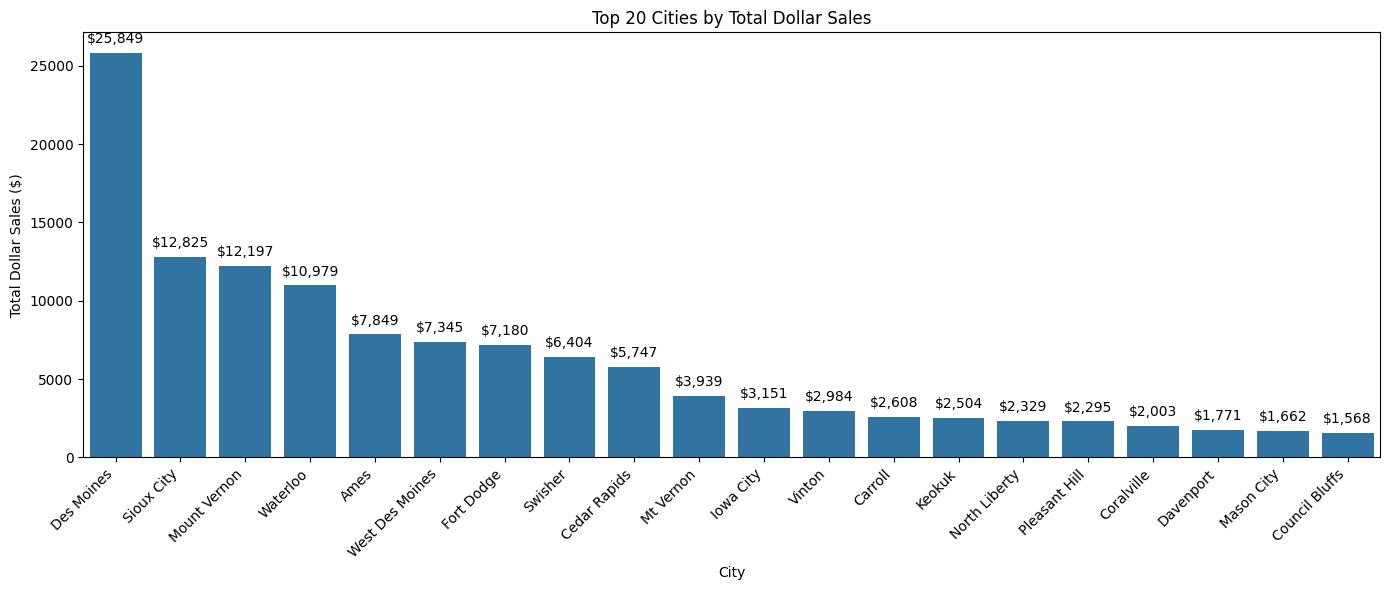

In [ ]:
plt.figure(figsize=(14, 6))
ax = sns.barplot(x='city', y='sale_dollars', data=top_20_cities_by_sales, order=top_20_cities_by_sales['city'])
plt.title('Top 20 Cities by Total Dollar Sales')
plt.xlabel('City')
plt.ylabel('Total Dollar Sales ($)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
# Annotate bars with exact dollar values
for p in ax.patches:
    ax.annotate(f'${p.get_height():,.0f}',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center',
                va='center',
                xytext=(0, 10),
                textcoords='offset points',
                fontsize=10,
                color='black')

This give us useful and interesting info about liquor sales in the state of Iowa. It is shown clearly that Des Moines is by far the city with the most liquor sales in dollars!

Maybe it could be beneficial to save this (and every future) as a new csv in order to save us from all the previous dataset handling. This is also something we can keep in mind even if it's not nessecery.

In [ ]:
top_20_cities_by_sales.to_csv('top_20_cities_by_sales.csv', index=False)

After this we shall continue with other visualizations but before this, the above graph may not have any importance if we don't specify first the corresponding time. According to the "date" column and as we can see in the data description up above (which I'll also desplay right down below) the min and max date that are containde in the dataset are 2012-01-17 and 2022-06-28 respectively. So the "Top 20 Cities by Total Dollar Sales", as every other future graph, refers to this - almost 10 years long period of time.

Now, taking under consideration the time range and the actual dollar sales, we can notice something strange. That's why critical thinking is super important. I am reffering to the fact that the total sales of every city is way too low for a 10 years period and it cannot correspond to the real-world liquor sales!

In order to solve this riddle (and before putting the blame to the dataset 😋) we have to examine again and understand the dataset.

In fact, the dataset don't refer to all liquor sales but in certain brands and even more specificaly to certain items or series of items within certain liquor brands, as we can see in the column item_description.

In [ ]:
df.describe()

,date,store_number,zip_code,county_number,category,vendor_number,item_number,pack,bottle_volume_ml,state_bottle_cost,state_bottle_retail,bottles_sold,sale_dollars,volume_sold_liters,volume_sold_gallons
count,200,200.00000,200.000000,199.000000,1.970000e+02,200.00000,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000
mean,2017-08-02 02:24:00,3658.46500,51367.520000,55.351759,1.167075e+06,279.87500,99695.930000,11.560000,841.975000,10.041200,15.065600,54.925000,717.367050,51.376500,13.570450
min,2012-01-17 00:00:00,2178.00000,50009.000000,3.000000,1.011300e+06,35.00000,168.000000,3.000000,20.000000,0.890000,1.340000,1.000000,6.750000,0.150000,0.030000
25%,2015-01-02 12:00:00,2593.00000,50401.000000,32.000000,1.051110e+06,107.50000,35916.000000,6.000000,750.000000,4.690000,7.040000,4.000000,46.867500,4.000000,1.060000
50%,2017-06-17 00:00:00,3509.00000,51301.000000,57.000000,1.081330e+06,303.00000,66772.500000,12.000000,750.000000,7.620000,11.430000,22.000000,206.640000,7.500000,1.980000
75%,2020-09-02 06:00:00,4358.75000,52314.000000,77.000000,1.091200e+06,421.00000,82847.500000,12.000000,1000.000000,15.000000,22.500000,66.000000,808.380000,55.125000,14.565000
max,2022-06-28 00:00:00,9001.00000,52807.000000,97.000000,1.901200e+06,662.00000,986845.000000,48.000000,1750.000000,34.990000,52.490000,900.000000,7240.860000,900.000000,237.750000
std,NaN,1207.00655,945.237701,27.128331,2.482830e+05,152.99154,195813.621412,6.895953,441.554727,6.986453,10.481138,108.227656,1214.452206,112.315307,29.670376


In [ ]:
# Calculate total sale_dollars for each item
item_sales = df.groupby('item_description')['sale_dollars'].sum().reset_index()

# Sort cities by total sale_dollars in descending order and select the top 20
top_20_items_by_sales = item_sales.sort_values(by='sale_dollars', ascending=False).head(20)

# Get the list of top 20 city names in the desired order
item_order = top_20_items_by_sales['sale_dollars'].tolist()

# Filter the original DataFrame to include only the top 20 cities by sales
filtered_item_data_by_sales = df[df['sale_dollars'].isin(item_order)]

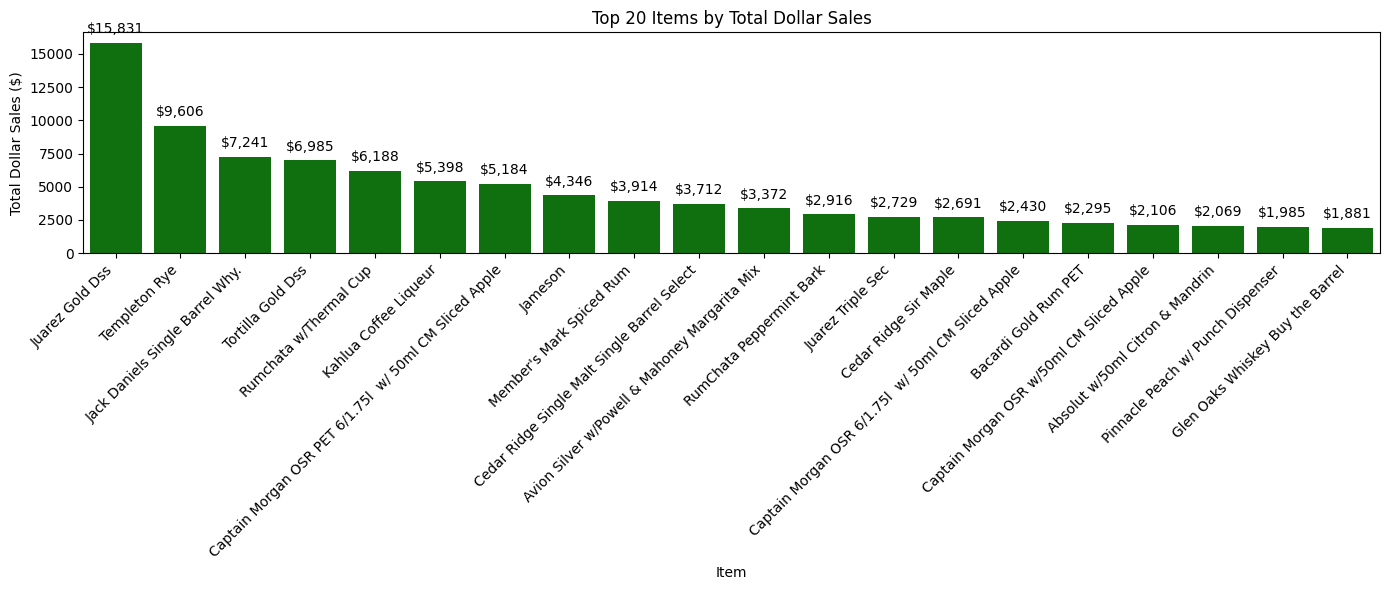

In [ ]:
# Your existing barplot code
plt.figure(figsize=(14, 6))
ax = sns.barplot(x='item_description', y='sale_dollars', data=top_20_items_by_sales, order=top_20_items_by_sales['item_description'], color='Green')
plt.title('Top 20 Items by Total Dollar Sales')
plt.xlabel('Item')
plt.ylabel('Total Dollar Sales ($)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
# Annotate bars with exact dollar values
for p in ax.patches:
    ax.annotate(f'${p.get_height():,.0f}',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center',
                va='center',
                xytext=(0, 10),
                textcoords='offset points',
                fontsize=10,
                color='black')

Similarly to the previous grap, the first item (Juarez Gold Dss) stands out.

Of course it will be super interesting to combine the two examined attribues (cities and items) and see if there is a relationship between the top cities and the most sold items.

In [ ]:
count_table = pd.crosstab(
    index=duplicates['city'],
    columns=top_20_items_by_sales['item_description'],
    normalize='index'  # Shows % of each item per city
)

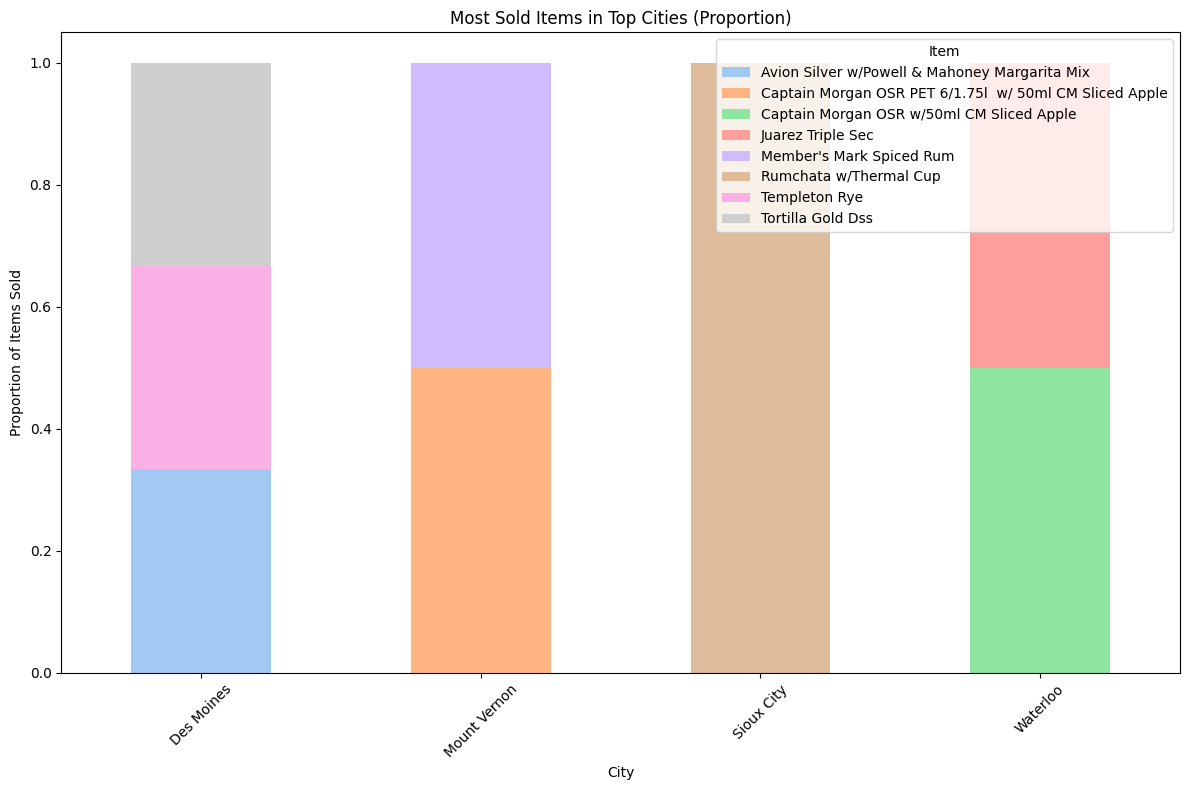

In [ ]:
count_table.plot(kind='bar', stacked=True, figsize=(12, 8))
plt.title('Most Sold Items in Top Cities (Proportion)')
plt.xlabel('City')
plt.ylabel('Proportion of Items Sold')
plt.xticks(rotation=45)
plt.legend(title='Item')
plt.tight_layout()
plt.show()

Of course this dataset is an educational one and its use it's all about personal practice. That is why the proportions of items are divided by so few parts or we don't have any overlap.

Although, the 8 items that rule in the sales of these top 4 cities are popular items that are found in the the top 11 places of the most-selling items in the whole state. That is something that make sense and satisfy as a result, but in constrast to this a couple of the most-selling items like Juarez Gold DSS and Jack Daniels Single Barrel do not exist in the above chart. This is quite unexpected and maybe we can conclude that the combined buying power and devotion of the smaller cities can make a difference overall.



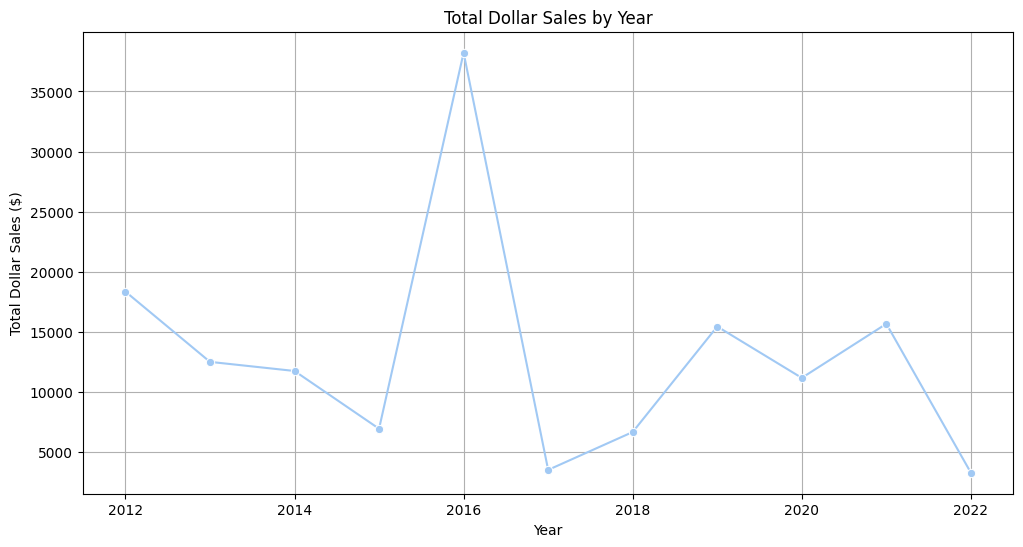

In [ ]:
df['year'] = df['date'].dt.year

yearly_sales = df.groupby('year')['sale_dollars'].sum().reset_index()

# Plot the yearly sales
plt.figure(figsize=(12, 6))
sns.lineplot(x='year', y='sale_dollars', data=yearly_sales, marker='o')
plt.title('Total Dollar Sales by Year')
plt.xlabel('Year')
plt.ylabel('Total Dollar Sales ($)')
plt.grid(True)
plt.show()

At first glance this seems off, and maybe it is, but before rejecting (or accepting) anything as truth I prefer to examine every info I can get. As I already told this is an aducational dataset but sometimes the truth can be not so easy to see. That's why it is always beneficial to cross-validate any findings or interesting outcomes with multiple sources and extract a well-examined conclusion.

My explanation try: In 2012 the sale are in mid levels. In the following months there is a fall (maybe due to raises in prices). The most interesting part is around the year of 2016 where there is a huge pic. This, if it happened indeed in the real-world, it has to do something with a govermantal law about liquor or alcohol distribution and sales in the U.S. or something like this. Then, after the 2017 fall (the last face of the "2016 law bubble) the sales get back more-or-less to normal levels until a new fall from 2021 to 2022 when they hit a new negative record. This last fall is probably due to the pandemic.

That was my first data analysis attemp and the first project of my portfolio! Many things could have gone a little smoothier but this was all practice and showcasing my interest in data analysis and my thoughts behind it.